# Skill Demand Analysis for Top Data Roles

## Project Objective

This analysis identifies the most in-demand skills for the three most popular data-related roles in the United States:

- Data Analyst
- Data Engineer
- Data Scientist

The goal is to understand which technical skills employers most frequently request and how skill requirements differ across roles.

## Methodology

1. Filter job postings for the United States.
2. Expand the skills column to analyze individual skills.
3. Calculate skill demand by job title.
4. Compare skill frequencies and percentages across roles.
5. Identify the most requested skills for each role.

## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_US = df[df['job_country'] == 'United States']

In [10]:
df_skills = df_US.explode('job_skills')

In [11]:
# Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

In [ ]:
job_titles = (
    df_US['job_title_short'].value_counts().head(3).index.tolist()
)

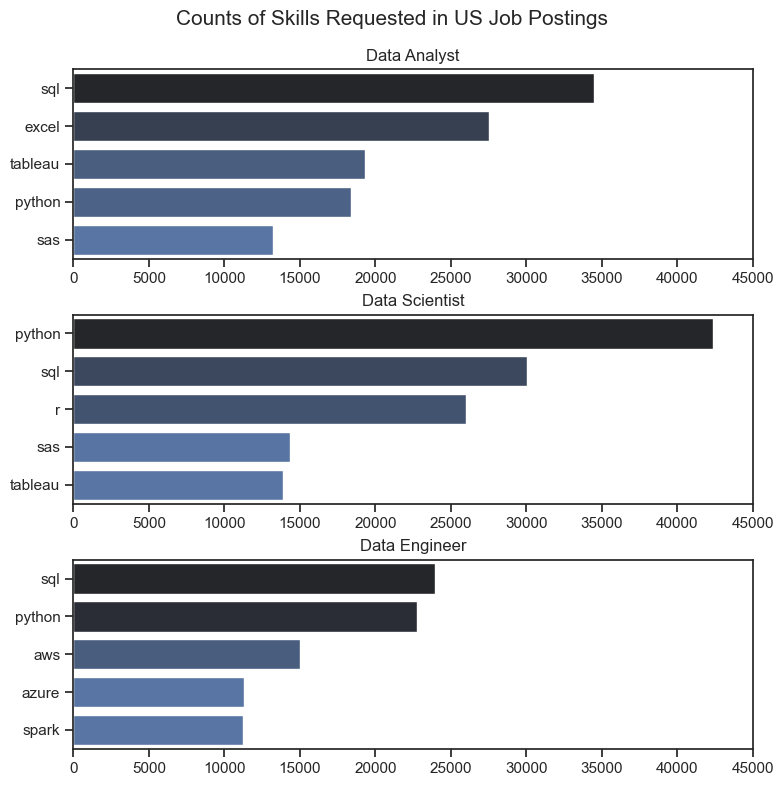

In [15]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8,8))

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 45000) # make the scales the same

fig.suptitle('Counts of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap
plt.show()

## Key Findings

- SQL and Python appear consistently among the most requested skills across data roles.
- Data Engineers show stronger demand for engineering and infrastructure skills.
- Data Scientists demonstrate higher demand for programming and machine learning tools.
- Data Analysts show stronger emphasis on SQL and business intelligence tools.

In [12]:
# Use original df to get the count of job titles
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [13]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

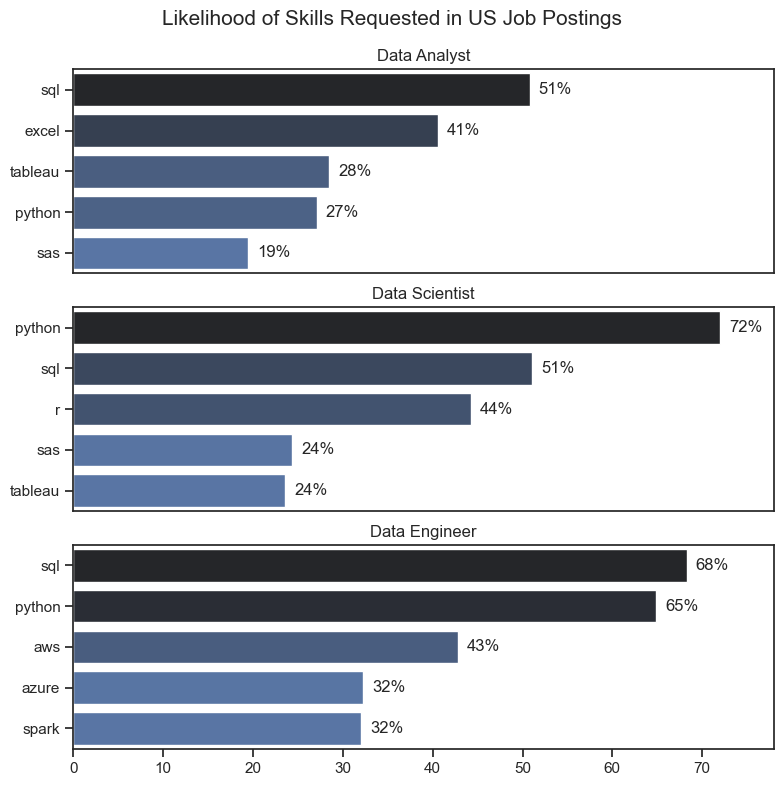

In [14]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8,8))


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()

## Key Findings

- SQL remains one of the most requested skills across all three roles.
- Skill requirements vary significantly depending on job function.
- Data Analyst positions prioritize analytical and reporting tools.
- Data Engineer positions prioritize data infrastructure and processing technologies.
- Data Scientist positions require a broader combination of programming and analytical skills.

## Conclusion

This analysis identified the most frequently requested skills for the three most popular data roles in the United States.

The results highlight that while SQL is a foundational skill across multiple roles, each position requires a distinct technical skill set. Understanding these differences can help job seekers prioritize the most relevant skills for their target career path.